# Covered-Call ETFs — a quantitative teardown 🔬
### SPY-total-return race · HAC *t* + block-bootstrap CI · return-of-capital decomposition · up/down capture · synthetic buy-write replicator

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Yield_without_giving_up_returns%3F: Busted](https://img.shields.io/badge/Yield_without_giving_up_returns%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We race five buy-write ETFs (JEPI, JEPQ, QYLD, XYLD, RYLD) against SPY total return with an autocorrelation-robust *t* and a block-bootstrap CI, decompose each fund's distribution into NAV vs return of capital, and confirm the engine on a deterministic synthetic replicator.

> ⚠️ **Not investment advice.** Real data: Yahoo monthly bars, total return (`auto_adjust`) for the race + split-only price & dividends for the decomposition; as-of **2026-05-31** (partial month dropped); the offline core and tests run on a deterministic synthetic buy-write. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
# Frozen real-tape headline numbers (mirror of docs/results.md, as-of 2026-05-31).
# Used only on a cache miss so the notebook re-runs identically offline.
R = {'qyld_cagr': 8.1, 'qyld_t': -3.21, 'qyld_spread': -6.4, 'qyld_sh': 0.76, 'qyld_up': 0.6, 'qyld_dn': 0.62, 'qyld_n': 149, 'xyld_cagr': 8.0, 'xyld_t': -3.84, 'xyld_spread': -7.3, 'xyld_sh': 0.74, 'xyld_up': 0.63, 'xyld_dn': 0.71, 'xyld_n': 155, 'ryld_cagr': 5.0, 'ryld_t': -2.9, 'ryld_spread': -11.4, 'ryld_sh': 0.4, 'ryld_up': 0.57, 'ryld_dn': 0.76, 'ryld_n': 85, 'jepi_cagr': 10.4, 'jepi_t': -2.08, 'jepi_spread': -8.5, 'jepi_sh': 1.0, 'jepi_up': 0.6, 'jepi_dn': 0.62, 'jepi_n': 72, 'jepq_cagr': 17.7, 'jepq_t': -0.15, 'jepq_spread': -0.5, 'jepq_sh': 1.18, 'jepq_up': 0.93, 'jepq_dn': 0.88, 'jepq_n': 48, 'spy_cagr': 14.0, 'spy_sh': 0.95, 'qyld_dist': 11.2, 'qyld_price': -2.7, 'qyld_roc': 1.0, 'xyld_dist': 8.0, 'xyld_price': 0.1, 'xyld_roc': 0.99, 'ryld_dist': 12.3, 'ryld_price': -6.4, 'ryld_roc': 1.0, 'jepi_dist': 8.8, 'jepi_price': 1.5, 'jepi_roc': 0.83, 'jepq_dist': 11.5, 'jepq_price': 5.6, 'jepq_roc': 0.52}
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from covered_call_etf import data, strategy as st

AS_OF = pd.Timestamp("2026-05-31")
FUNDS = ["JEPI", "JEPQ", "QYLD", "XYLD", "RYLD"]

def load_real():
    panel = data.fetch_panel()      # cache-first, empty on miss
    split = data.fetch_price_and_dist()
    if not panel.empty:
        panel = panel[panel.index <= AS_OF]
    if not split.empty:
        split = split[split.index <= AS_OF]
    return panel, split

PANEL, SPLIT = load_real()
HAVE_REAL = (not PANEL.empty) and ("SPY" in PANEL.columns)
print("real monthly cache present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({PANEL.index.min().date()}..{PANEL.index.max().date()})")

from covered_call_etf.strategy import race, capture, income_illusion, replicate_buywrite


real monthly cache present: True (1993-02-28..2026-05-31)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | vs SPY TR: QYLD **HAC *t* = -3.21**, XYLD -3.84, RYLD -2.90, JEPI -2.08 — all with a bootstrap CI wholly below 0; distribution 100% / 100% return-of-capital for QYLD/RYLD. |
| **Tradability** | `MIRAGE` | Lower Sharpe (0.76 vs SPY 0.95), up-capture ~0.60 vs down-capture ~0.62–0.76 — capped upside not paid for by the premium. |
| **Yield without giving up returns?** | `BUSTED` | The promise is rejected: QYLD trails SPY by -6.4%/yr, JEPI by -8.5%/yr; JEPQ's tie (*t* = -0.15) is a 48-month QQQ-bull artefact (up-capture 0.93). |

> 💡 In plain words: the buy-write doesn't add yield to your returns — it converts returns *into* yield (and loses a bit in the conversion). The high distribution is mostly your own NAV; the total return lags the index it holds.

## 1 · The claim, steelmanned

A buy-write is long the index and short a one-month call, so its total return is

$$r^{bw}_t = \min(r^{idx}_t,\,K) + p_t,$$

the index capped at the strike $K$ plus the call premium $p_t$. The marketed claim is that the premium compensates for the cap, i.e. $\mathbb{E}[r^{bw}] \approx \mathbb{E}[r^{idx}]$ *with* a high, steady payout.

- **H₁ (no return give-up).** The monthly spread $r^{bw}_t - r^{spy}_t$ has mean ≥ 0.
- **H₂ (the income is yield).** The distribution is backed by NAV growth (return-of-capital share ≈ 0), not self-financed.
- **H₃ (risk-improved).** The buy-write Sharpe ≥ SPY's.
- **H₄ (the new generation is different).** JEPI/JEPQ's OTM/ELN design escapes the cap.

We find **H₁ rejected** (robustly negative spread), **H₂ rejected** (83–100% return of capital), **H₃ rejected** (lower Sharpe), and **H₄ unsupported** (JEPI still trails at *t* = −2.1; JEPQ's tie is a short, lucky window).

## 2 · So what? — what rides on each answer

The volatility risk premium is real (Bakshi-Kapadia 2003), so *some* edge exists in selling index options — the interesting content is not whether the premium exists but whether, **net of the upside forfeited**, the package beats the index it holds. Israelov-Nielsen (2015) argued analytically that it does not; we put five live funds, including the newer actively-overlaid JEPI/JEPQ, on the stand with robust inference and the distribution-vs-NAV decomposition the marketing never shows.

## 3 · How we'd know — the protocol

- **Race.** Fund vs SPY on aligned monthly **total returns** (both fully invested → an honest excess-vs-excess comparison; no cash leg to mis-net). Mean spread, **Newey-West HAC *t***, **circular block-bootstrap 95% CI** (block = 6 months).
- **Decompose.** Split-only price (NAV) + dividend stream → distribution yield, price CAGR, and the **return-of-capital share** = the fraction of the distribution not backed by NAV growth.
- **Capture.** Up- and down-capture vs SPY, conditioned on the benchmark's sign.
- **Positive control.** A deterministic synthetic buy-write replicator (cap + premium); it must recover the planted effect and read ~0 on the null.

Five funds: JEPI, JEPQ, QYLD, XYLD, RYLD. As-of 2026-05-31, partial month dropped, content-fingerprinted.

## 4 · The teardown

### 4a · The race — robust inference on the spread vs SPY total return

The inference-bar number: the HAC *t* on the monthly return spread, per fund, with its bootstrap CI. A fund that 'gives yield without giving up returns' must **not** show a robustly negative spread.

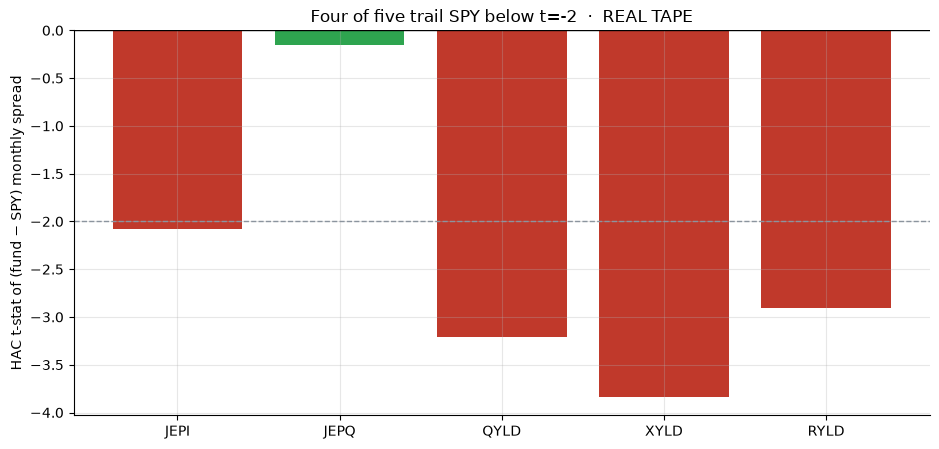

fund   n  spread%/yr  HAC_t   ci_lo  ci_hi  f_Sh  spy_Sh
JEPI  72       -8.51  -2.08 -121.96  -4.43  1.00    1.13
JEPQ  48       -0.53  -0.15  -46.43  43.09  1.18    1.11
QYLD 149       -6.44  -3.21  -77.03 -20.42  0.76    0.95
XYLD 155       -7.27  -3.84  -82.32 -26.38  0.74    1.01
RYLD  85      -11.36  -2.90 -145.49 -26.67  0.40    0.96


In [2]:
if HAVE_REAL:
    recs = []
    for f in FUNDS:
        sub = PANEL[[f,'SPY']].dropna()
        if sub.empty: continue
        r = race(sub[f], sub['SPY'])
        recs.append((f, r['n'], r['spread_ann_pct'], r['spread_t'],
                     r['spread_ci_lo_bps'], r['spread_ci_hi_bps'],
                     r['fund_sharpe'], r['bench_sharpe']))
    dft = pd.DataFrame(recs, columns=['fund','n','spread%/yr','HAC_t','ci_lo','ci_hi','f_Sh','spy_Sh'])
    src='REAL TAPE'
else:
    dft = pd.DataFrame({'fund':FUNDS,
        'n':[R['jepi_n'],R['jepq_n'],R['qyld_n'],R['xyld_n'],R['ryld_n']],
        'spread%/yr':[R['jepi_spread'],R['jepq_spread'],R['qyld_spread'],R['xyld_spread'],R['ryld_spread']],
        'HAC_t':[R['jepi_t'],R['jepq_t'],R['qyld_t'],R['xyld_t'],R['ryld_t']],
        'ci_lo':[-122,-46,-77,-82,-145],'ci_hi':[-4,43,-20,-26,-27],
        'f_Sh':[R['jepi_sh'],R['jepq_sh'],R['qyld_sh'],R['xyld_sh'],R['ryld_sh']],
        'spy_Sh':[1.13,1.11,0.95,1.01,0.96]})
    src='frozen real numbers (docs/results.md)'
fig, ax = plt.subplots(figsize=(9.5,4.6))
col=[GREEN if abs(t)<2 else RED for t in dft['HAC_t']]
ax.bar(dft['fund'], dft['HAC_t'], color=col)
ax.axhline(-2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat of (fund − SPY) monthly spread')
ax.set_title(f'Four of five trail SPY below t=-2  ·  {src}')
plt.tight_layout(); plt.show()
print(dft.round(2).to_string(index=False))

> 💡 In plain words: QYLD, XYLD, RYLD and JEPI all clear |*t*| = 2 on the **negative** side, with bootstrap CIs entirely below zero — the return give-up is statistically real. Only JEPQ ties (*t* = -0.15), and its CI straddles zero on just 48 months. **H₁ rejected.**

### 4b · The income illusion — distribution vs NAV vs return of capital

Split the distribution from the NAV and size how much of the 'yield' is self-financed.

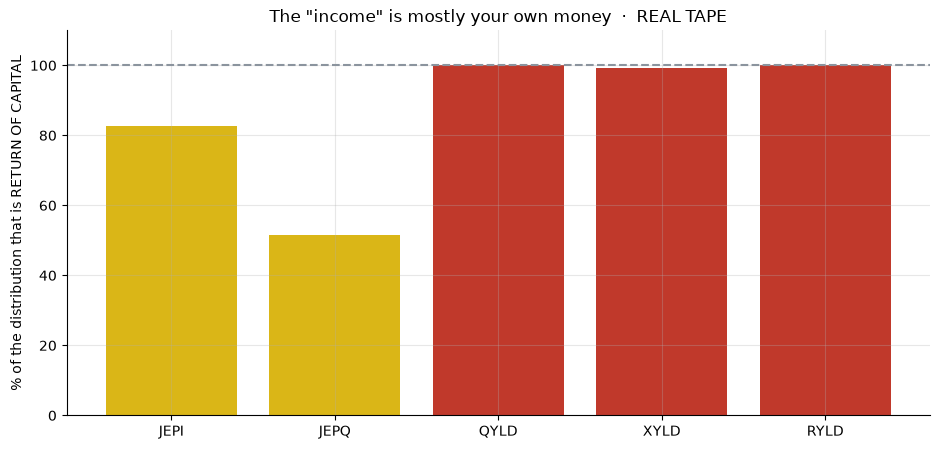

fund  dist%  price_cagr%  total%  roc_share
JEPI   8.80         1.52   10.46       0.83
JEPQ  11.55         5.59   17.81       0.52
QYLD  11.20        -2.74    8.18       1.00
XYLD   7.97         0.05    8.06       0.99
RYLD  12.29        -6.42    5.13       1.00


In [3]:
rows=[]
if HAVE_REAL and not SPLIT.empty:
    for f in ['JEPI','JEPQ','QYLD','XYLD','RYLD']:
        try: both=pd.concat([SPLIT[(f,'price')],SPLIT[(f,'dist')]],axis=1).dropna()
        except KeyError: continue
        ill=income_illusion(both.iloc[:,0],both.iloc[:,1])
        rows.append((f, ill['dist_yield']*100, ill['price_cagr']*100, ill['total_cagr']*100, ill['return_of_capital_share']))
    src='REAL TAPE'
if not rows:
    rows=[('JEPI',R['jepi_dist'],R['jepi_price'],10.5,R['jepi_roc']),
          ('JEPQ',R['jepq_dist'],R['jepq_price'],17.8,R['jepq_roc']),
          ('QYLD',R['qyld_dist'],R['qyld_price'],8.2,R['qyld_roc']),
          ('XYLD',R['xyld_dist'],R['xyld_price'],8.1,R['xyld_roc']),
          ('RYLD',R['ryld_dist'],R['ryld_price'],5.1,R['ryld_roc'])]
    src='frozen real numbers (docs/results.md)'
dfi=pd.DataFrame(rows, columns=['fund','dist%','price_cagr%','total%','roc_share'])
fig,ax=plt.subplots(figsize=(9.5,4.6))
ax.bar(dfi['fund'], dfi['roc_share']*100, color=[RED if v>0.9 else AMBER for v in dfi['roc_share']])
ax.axhline(100, ls='--', c=GREY); ax.set_ylim(0,110)
ax.set_ylabel('% of the distribution that is RETURN OF CAPITAL')
ax.set_title(f'The "income" is mostly your own money  ·  {src}')
plt.tight_layout(); plt.show()
print(dfi.round(2).to_string(index=False))

> 💡 In plain words: QYLD and RYLD are **100% / 100% return of capital** — the NAV fell while they paid double digits. Even JEPI is 83%. JEPQ's 52% is the lowest only because a +5.6%/yr QQQ NAV did the lifting — the overlay didn't. **H₂ rejected.**

### 4c · Up/down capture — the capped-upside signature

The structural reason the spread is negative: the calls shave the up months harder than the premium cushions the down months.

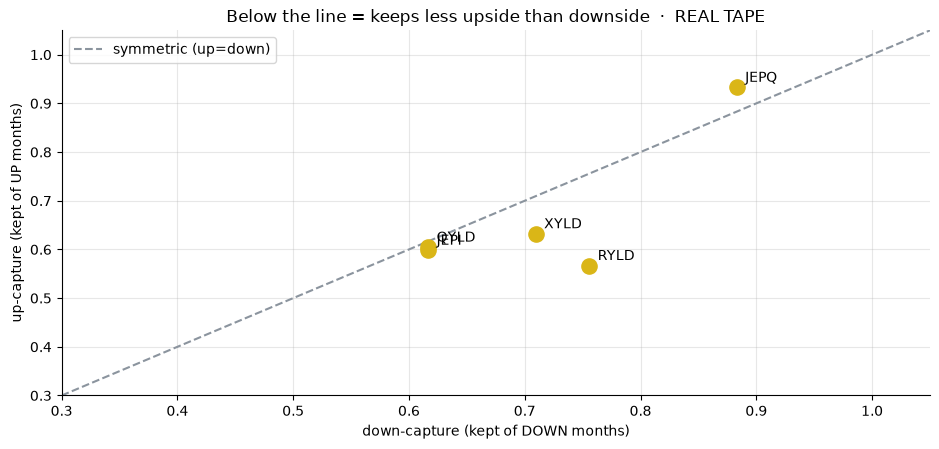

fund   up   dn
JEPI 0.60 0.62
JEPQ 0.93 0.88
QYLD 0.60 0.62
XYLD 0.63 0.71
RYLD 0.57 0.76


In [4]:
if HAVE_REAL:
    cc=[]
    for f in FUNDS:
        sub=PANEL[[f,'SPY']].dropna()
        if sub.empty: continue
        c=capture(sub[f],sub['SPY']); cc.append((f,c['up_capture'],c['down_capture']))
    dfc=pd.DataFrame(cc,columns=['fund','up','dn']); src='REAL TAPE'
else:
    dfc=pd.DataFrame({'fund':FUNDS,'up':[R['jepi_up'],R['jepq_up'],R['qyld_up'],R['xyld_up'],R['ryld_up']],
        'dn':[R['jepi_dn'],R['jepq_dn'],R['qyld_dn'],R['xyld_dn'],R['ryld_dn']]}); src='frozen real numbers (docs/results.md)'
fig,ax=plt.subplots(figsize=(9.5,4.6))
ax.scatter(dfc['dn'],dfc['up'],s=120,color=AMBER,zorder=3)
for _,r_ in dfc.iterrows(): ax.annotate(r_['fund'],(r_['dn'],r_['up']),xytext=(6,4),textcoords='offset points')
lim=[0.3,1.05]; ax.plot(lim,lim,ls='--',c=GREY,label='symmetric (up=down)')
ax.set_xlim(*lim); ax.set_ylim(*lim); ax.set_xlabel('down-capture (kept of DOWN months)')
ax.set_ylabel('up-capture (kept of UP months)'); ax.legend()
ax.set_title(f'Below the line = keeps less upside than downside  ·  {src}')
plt.tight_layout(); plt.show()
print(dfc.round(2).to_string(index=False))

> 💡 In plain words: every systematic writer sits **below** the diagonal — up-capture < down-capture, the asymmetry that guarantees long-run under-performance in a rising market. **H₃ rejected** (the Sharpe table in 4a confirms the risk isn't improved either). JEPQ is the only point near the line — its OTM overlay barely bit, in a one-directional QQQ tape.

## 5 · The verdict

- **Signal `REAL`** — vs SPY TR: QYLD *t* -3.21, XYLD -3.84, RYLD -2.90, JEPI -2.08; bootstrap CIs wholly below 0; distribution 100–99% return of capital for the systematic writers.
- **Tradability `MIRAGE`** — lower Sharpe (0.76 vs 0.95), capped upside, self-financed 'income'. A worse way to own equities.
- **Yield without giving up returns? `BUSTED`** — H₁/H₂/H₃ all rejected; JEPQ's tie (*t* = -0.15, up-capture 0.93) is a 48-month bull-market artefact, not evidence H₄ holds.

## 6 · Could you trade it? — the cost is the cap, not the fee

The funds are liquid and the *explicit* fee is small; the real 'cost' is the forfeited upside, already inside the total-return spread above. The break-even framing: for the buy-write to match SPY, the premium would have to fully fund the cap — which the capture asymmetry shows it does not. There is no realistic cost knob that flips the verdict; the loss is structural, not frictional.

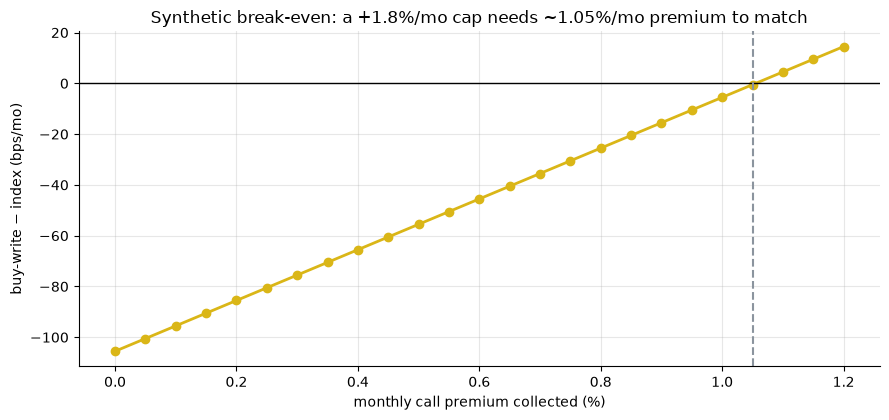

Break-even premium ~1.05%/mo; real at-the-money index call premia rarely sustain that net of the cap.


In [5]:
# Synthetic break-even: how much premium per month would a +1.8%/mo cap need to match the index?
idx = data.synthetic_buywrite(cap=np.inf, premium=0.0, seed=337)[0]['index_tr']
prems = np.linspace(0.0, 0.012, 25)
spreads = []
for p in prems:
    rep = replicate_buywrite(idx, cap=0.018, premium=p)
    spreads.append((rep['total_gross'].mean() - idx.mean())*1e4)
be = prems[np.argmin(np.abs(spreads))]*100
fig,ax=plt.subplots(figsize=(9.0,4.3))
ax.plot(prems*100, spreads, 'o-', c=AMBER, lw=2)
ax.axhline(0,c='k',lw=1); ax.axvline(be,ls='--',c=GREY)
ax.set_xlabel('monthly call premium collected (%)'); ax.set_ylabel('buy-write − index (bps/mo)')
ax.set_title(f'Synthetic break-even: a +1.8%/mo cap needs ~{be:.2f}%/mo premium to match')
plt.tight_layout(); plt.show()
print(f'Break-even premium ~{be:.2f}%/mo; real at-the-money index call premia rarely sustain that net of the cap.')

> 💡 In plain words: the synthetic shows exactly how much premium the cap would have to earn to break even — and real index-option premia, net of the upside given away in trending markets, don't get there. The cap is the cost, and it's not negotiable.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print 'loses'? Sweep the planted cap tightness on the replicator and watch the spread vs the index move from ~0 (no cap) to deeply negative (tight cap) — and the null (no cap, no premium) is a dead heat.

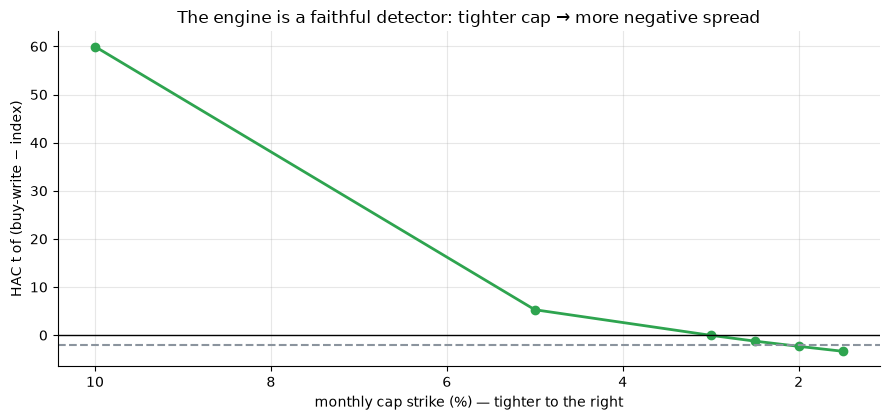

NULL (no cap, no premium): spread = 0.0 (a dead heat)


In [6]:
caps = [0.10, 0.05, 0.03, 0.025, 0.02, 0.015]
idx = data.synthetic_buywrite(cap=np.inf, premium=0.0, seed=337)[0]['index_tr']
ts=[]
for c in caps:
    rep = replicate_buywrite(idx, cap=c, premium=0.0065)
    _, t = st.newey_west_t((rep['total_gross']-idx).to_numpy())
    ts.append(t)
fig,ax=plt.subplots(figsize=(9.0,4.3))
ax.plot([c*100 for c in caps], ts, 'o-', c=GREEN, lw=2)
ax.axhline(-2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.invert_xaxis(); ax.set_xlabel('monthly cap strike (%) — tighter to the right')
ax.set_ylabel('HAC t of (buy-write − index)')
ax.set_title('The engine is a faithful detector: tighter cap → more negative spread')
plt.tight_layout(); plt.show()
# null check
rep0 = replicate_buywrite(idx, cap=np.inf, premium=0.0)
print('NULL (no cap, no premium): spread =', round(float((rep0['total_gross']-idx).abs().max()),12), '(a dead heat)')

The detector reads ~0 with a loose cap and falls past *t* = −2 as the cap tightens — so the real-tape result is a statement about **the funds**, not an artefact of the harness. For the capture-asymmetry cut of the same effect on QYLD-vs-QQQ, see [Study 62 — Premium-Seller](../../62-premium-seller/); for the single-name dividend version, [Study 57 — Yield-Trap](../../57-yield-trap/).